In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from IPython.display import display


### PARAMS

In [2]:
T = 128  # Порог 
image_path = "Тестовые изображения/01_apc.tif"

In [3]:
def load_img(path_name):
    img = Image.open(path_name).convert("L")
    return np.array(img, dtype=np.uint8)

In [4]:
def analyze_image(matrix, title="Исходное"):
    """
    Считывает изображение (из пути или объекта),
    строит гистограмму яркости и печатает информацию.
    """

    width, height = matrix.shape
    total_pixels = width * height

    # Матрица и гистограмма
    arr = matrix.flatten()
    #hist, _ = np.histogram(arr, bins=np.arange(257))

    # Печать информации
    print(f"Разрешение: {width} × {height} пикселей")
    print(f"Количество пикселей: {total_pixels}")
    print(f"Минимальная яркость: {arr.min()}, максимальная: {arr.max()}, средняя: {arr.mean():.2f}")

    # Гистограмма
    plt.figure()
    plt.hist(arr, bins=range(256), width=2)
    plt.title(f"Гистограмма яркости (0–255) {title}")
    plt.xlabel("Яркость")
    plt.ylabel("Частота")
    plt.xlim(0, 255)
    plt.tight_layout()
    plt.show()

    return {
        "width": width,
        "height": height,
        "total_pixels": total_pixels,
        "matrix": matrix
    }

In [5]:
def show_image(matrix, title):
     # гарантируем ndarray uint8
    if hasattr(matrix, "dtype"):
        arr = matrix
    else:
        # если прилетела PIL.Image
        arr = np.array(matrix, dtype=np.uint8)
    
    # Настроим размер вывода (в дюймах, 1 дюйм ≈ 96px)
    plt.figure(figsize=(4, 4))
    plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
    plt.title(title)   # подпись сверху
    plt.axis("off")  # скрыть оси, чтобы был «чистый» вывод

    plt.show()

## 1. Пороговая обработка.

ВЫХОД:
1) Исходное изображение

2) Изображение после пороговой обработки

3) Исходная гистограмма

4) Гистограмма после пороговой обработки

5) График функции поэлементного преобразования

In [6]:
## Пороговая обработка.
def t_porog(name_path, t): 

    path = Path(name_path)
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    img = Image.open(path).convert("L")
    matrix = np.array(img, dtype=np.uint8)
    

    x = np.arange(256)                # входные значения яркости
    y = np.where(x < t, 0, 255)       # выход по правилу

    plt.figure()
    plt.plot(x, y, drawstyle="steps-post", color="red")
    plt.title(f"Функция поэлементного преобразования (T={t})")
    plt.xlabel("Входная яркость (x)")
    plt.ylabel("Выходная яркость g(x)")
    plt.grid(True)
    plt.show()
    
    return np.where(matrix >= t, 255, 0)


Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 12, максимальная: 215, средняя: 127.19


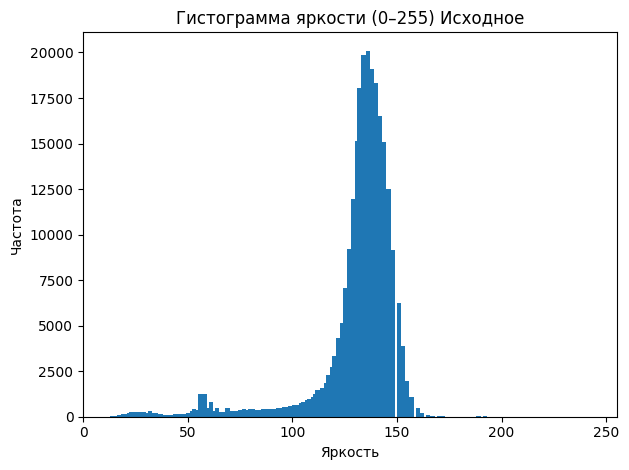

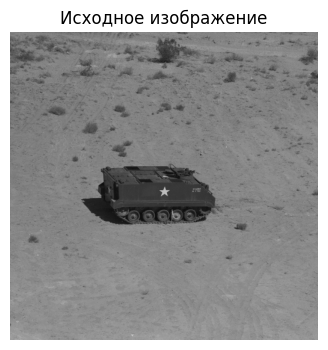

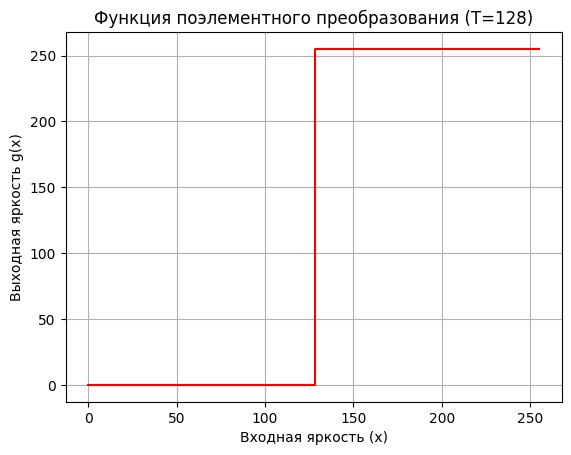

Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 0, максимальная: 255, средняя: 184.67


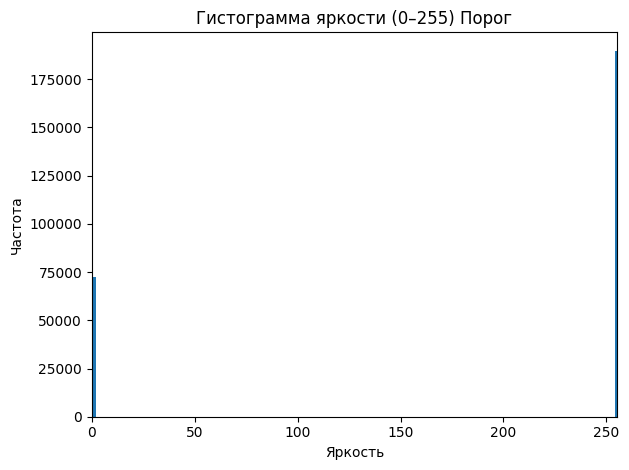

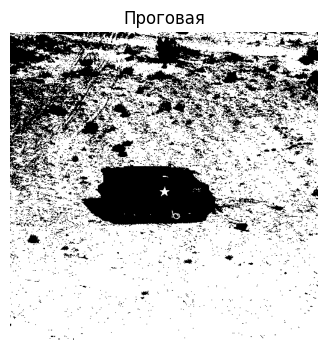

In [7]:


matrix = load_img(image_path)
info = analyze_image(matrix)
show_image(info["matrix"], "Исходное изображение")


porogimg = t_porog(image_path, T)
infoporog = analyze_image(porogimg, title="Порог")
show_image(infoporog["matrix"], "Проговая")


## 2. Контрастирование

ВЫХОД:
1) Исходное изображение

2) Контрастированное изображение

3) Исходная гистограмма

4) Гистограмма после контрастирования

5) График функции поэлементного преобразования

In [8]:
def contrast(matrix, gmin, gmax):

    fmax = int(np.max(matrix))
    fmin = int(np.min(matrix))

    a = (gmax - gmin) / (fmax - fmin)
    b = (gmin * fmax - gmax* fmin) / (fmax - fmin)
    

    matrix = a * matrix + b

    return matrix



Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 12, максимальная: 215, средняя: 127.19


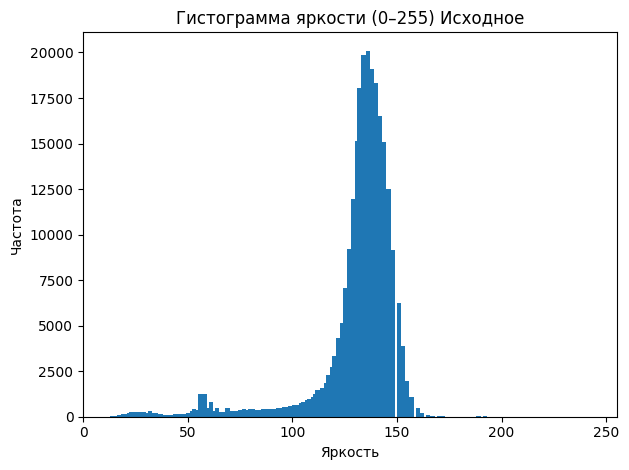

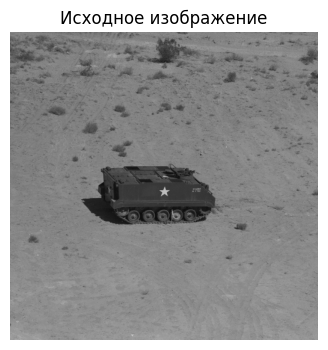

Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: -1.7763568394002505e-15, максимальная: 255.0, средняя: 144.69


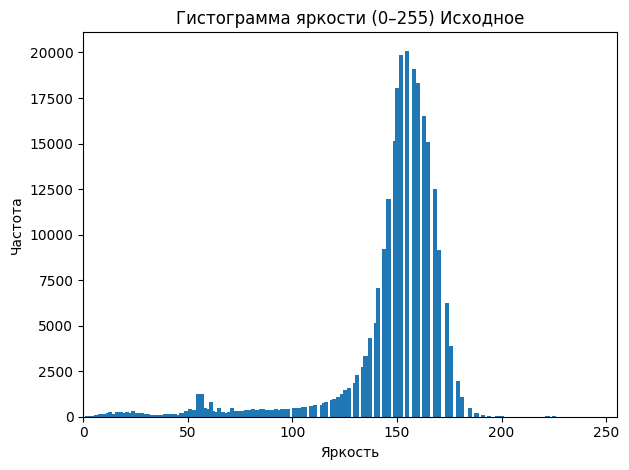

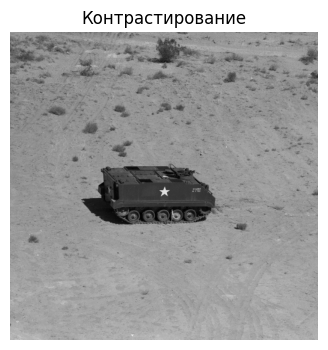

In [9]:
matrix = load_img(image_path)
info = analyze_image(matrix)
show_image(info["matrix"], "Исходное изображение")



matrixContrast = contrast(matrix,0,255)

infoContrast = analyze_image(matrixContrast)
show_image(infoContrast["matrix"], "Контрастирование")

## 3. Эквализация

1) Исходное изображение

2) Изображение после эквализации (стандратной и самописной)

3) График интегральной функции распределения яркости (до и после обработки)

4) Гистограмма исходного изображения

5) Гистограмма изображения после эквализации (стандартной и самописной)

6) График функции поэлементного преобразования

7) Выдать в консоль функцией типа print массивы гистограммы исходного изображения

и границ интервалов этой гистограммы, выданные функцией

hist, bins = histogram(...

Продемонстрировать, что массив границ интервалов bins

начинается с нуля и содержит числа 0 1 2 3 .. 255 256

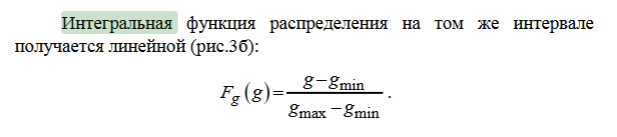

In [ ]:


def equalize(matrix, maxg=255, ming=0):
    # h массив длиной 256, где h[k] = сколько пикселей имеют яркость k
    h, bins = np.histogram(matrix, bins=256, range=(0, 256))
    cdf = np.cumsum(h)
    N = cdf[-1]
    
    # 3) Минимальное ненулевое значение CDF (сдвиг пустого хвоста)
    nz = cdf > 0
    cdf_min = min(nz)

    # Нормированная CDF:
    denom = max(N - cdf_min, 1)
    cdf_norm = (cdf - cdf_min) / denom

    # Построение функции преобразования
    g = (maxg - ming) * cdf_norm + ming
    mapping = np.clip(np.rint(g), 0, 255).astype(np.uint8)

    # 6) Применение преобразования
    new_matrix = mapping[matrix]

    # 7) График функции поэлементного преобразования
    f = np.arange(256)
    plt.figure()
    plt.plot(f, mapping, color="blue")
    plt.title("Функция поэлементного преобразования (эквализация) тут по хорошему 2 графика должно быть")
    plt.xlabel("f (вход)")
    plt.ylabel("g(f) (выход)")
    plt.xlim(0, 255); plt.ylim(0, 255)
    plt.grid(True)
    plt.show()

    return new_matrix


Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 12, максимальная: 215, средняя: 127.19


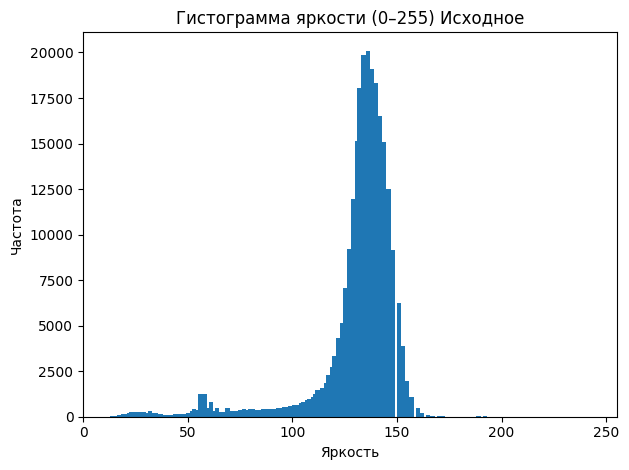

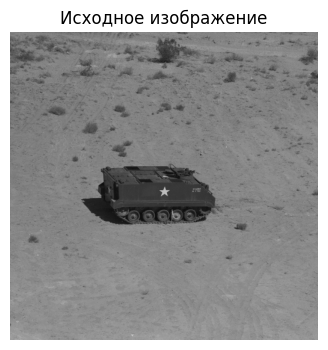

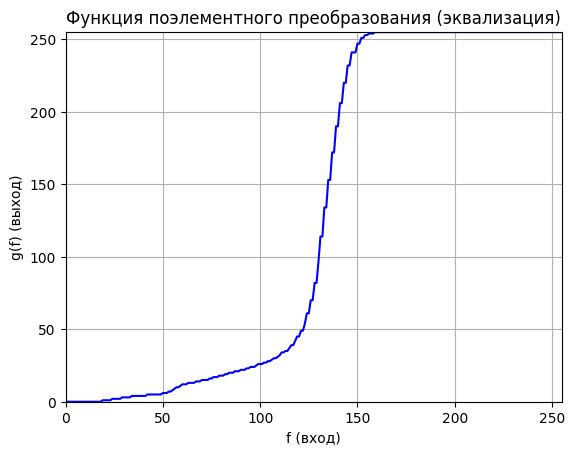

Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 0, максимальная: 255, средняя: 133.51


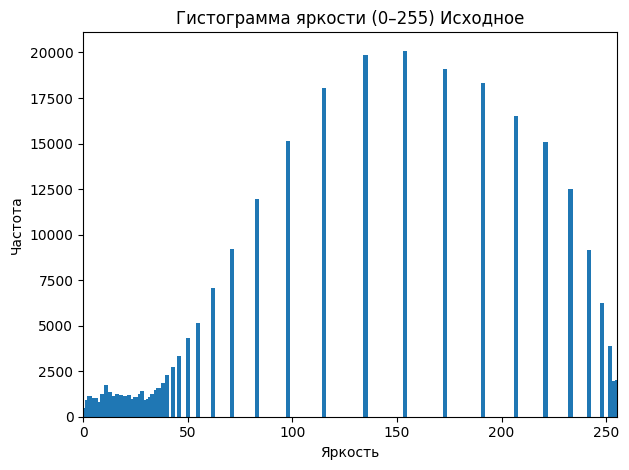

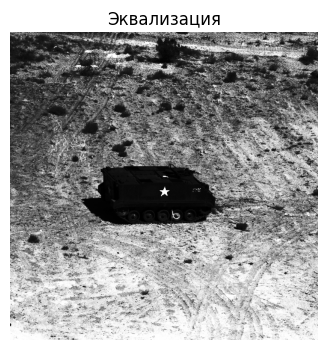

In [11]:
matrix = load_img(image_path)
info = analyze_image(matrix)
show_image(info["matrix"], "Исходное изображение")



matrixEqulize = equalize(matrix)

infoEqulize = analyze_image(matrixEqulize)
show_image(infoEqulize["matrix"], "Эквализация")